# Gradient Descent and Stochastic Gradient Descent

This notebook has two main parts:

### Section A — Geometry on the Rosenbrock Function
- 2D Rosenbrock function
- 3D surface and contour plots
- Gradient Descent (GD) vs. noisy "SGD" to illustrate trajectories in a tricky landscape

### Section B — True SGD as a Sum over Data Points (Logistic Regression)
- Synthetic 1D logistic regression dataset
- Modular setup: model, loss, full gradient, and per-sample gradient
- GD vs. true SGD (single-sample updates)

The plotting style uses `classlib.nbviz` when available and falls back to default Matplotlib otherwise.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

nbviz_available = False
try:
    import classlib as cl
    cl.nbviz.init(usetex=False)
    nbviz_available = True
    print('Initialized nbviz style from classlib.')
except Exception as e:
    print('classlib.nbviz not available; using default matplotlib style.')
    print('Reason:', e)

np.random.seed(42)

classlib.nbviz not available; using default matplotlib style.
Reason: init() got an unexpected keyword argument 'usetex'


## Section A — Geometry of Gradient Methods on the Rosenbrock Function

The 2D Rosenbrock function is
\begin{align}
f(x, y) = (1 - x)^2 + 100 (y - x^2)^2.
\end{align}

It has a narrow, curved valley and is a classic test problem for optimization algorithms.
Here we use it to build geometric intuition for gradient-based methods.

In [2]:
def rosenbrock_2d(x):
    x1, x2 = x
    return (1.0 - x1)**2 + 100.0 * (x2 - x1**2)**2

def grad_rosenbrock_2d(x):
    x1, x2 = x
    dfdx1 = -2.0 * (1.0 - x1) - 400.0 * x1 * (x2 - x1**2)
    dfdx2 = 200.0 * (x2 - x1**2)
    return np.array([dfdx1, dfdx2])

### 3D Surface Plot

We first visualize the Rosenbrock function as a surface to see the characteristic valley.

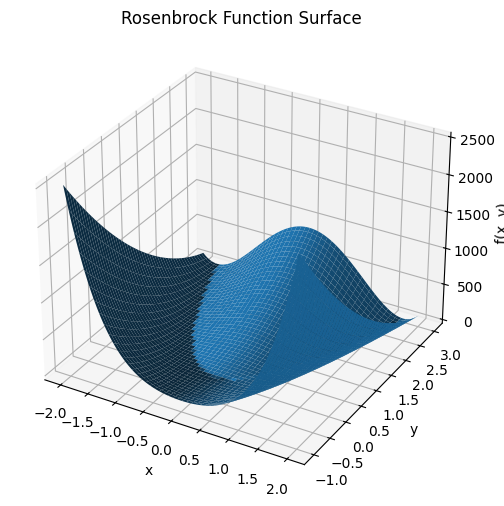

In [3]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

x = np.linspace(-2, 2, 200)
y = np.linspace(-1, 3, 200)
X, Y = np.meshgrid(x, y)
Z = (1.0 - X)**2 + 100.0 * (Y - X**2)**2

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, rstride=4, cstride=4, linewidth=0, antialiased=True)
ax.set_title('Rosenbrock Function Surface')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')
plt.show()

if nbviz_available:
    cl.nbviz.savefig('rosenbrock_surface')

### Gradient Descent vs Noisy Gradient Descent on 2D Rosenbrock

Here we compare:
- **Gradient Descent (GD)**: exact gradient of the Rosenbrock function.
- **Noisy GD**: gradient plus Gaussian noise at each step, mimicking stochastic gradients.

This does not correspond to an actual sum over data points, but it shows how noise in the
update can affect the trajectory in a complicated landscape.

In [4]:
def gradient_descent_2d(x0, lr=1e-3, steps=5000):
    x = np.array(x0, dtype=float)
    path = [x.copy()]
    fvals = [rosenbrock_2d(x)]
    for k in range(steps):
        g = grad_rosenbrock_2d(x)
        x = x - lr * g
        path.append(x.copy())
        fvals.append(rosenbrock_2d(x))
    return np.array(path), np.array(fvals)

def noisy_gd_2d(x0, lr=1e-3, steps=5000, noise_std=0.5):
    x = np.array(x0, dtype=float)
    path = [x.copy()]
    fvals = [rosenbrock_2d(x)]
    for k in range(steps):
        g = grad_rosenbrock_2d(x)
        g_noisy = g + noise_std * np.random.randn(2)
        x = x - lr * g_noisy
        path.append(x.copy())
        fvals.append(rosenbrock_2d(x))
    return np.array(path), np.array(fvals)

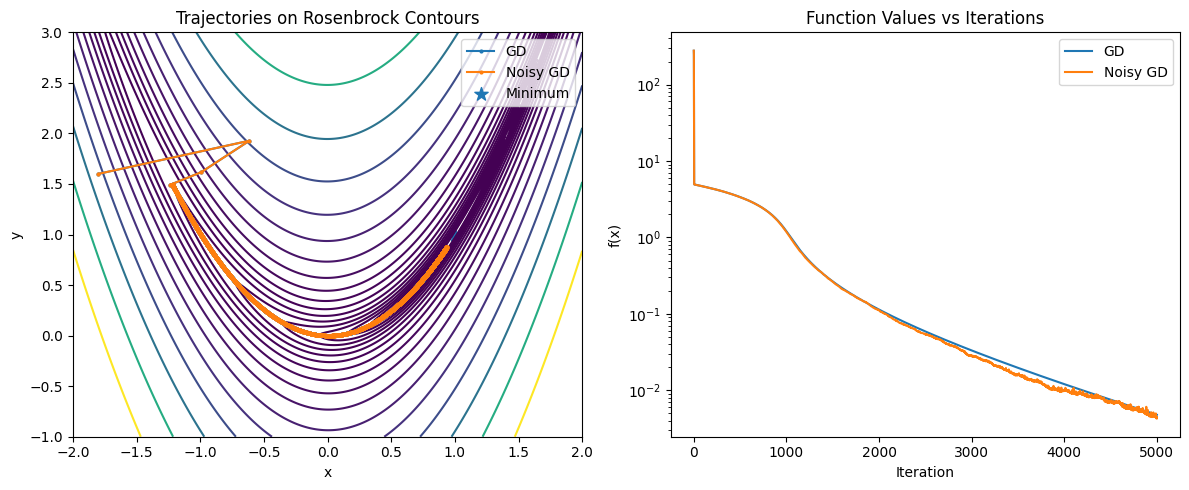

In [5]:
x0 = np.array([-1.8, 1.6])

path_gd, fvals_gd = gradient_descent_2d(x0, lr=1e-3, steps=5000)
path_ngd, fvals_ngd = noisy_gd_2d(x0, lr=1e-3, steps=5000, noise_std=0.5)

x = np.linspace(-2, 2, 400)
y = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x, y)
Z = (1.0 - X)**2 + 100.0 * (Y - X**2)**2

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

ax = axs[0]
cs = ax.contour(X, Y, Z, levels=np.logspace(-1, 3, 20))
ax.plot(path_gd[:, 0], path_gd[:, 1], '-', marker='o', markersize=2, label='GD')
ax.plot(path_ngd[:, 0], path_ngd[:, 1], '-', marker='o', markersize=2, label='Noisy GD')
ax.scatter([1.0], [1.0], marker='*', s=100, label='Minimum')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Trajectories on Rosenbrock Contours')
ax.legend()

ax = axs[1]
ax.semilogy(fvals_gd, label='GD')
ax.semilogy(fvals_ngd, label='Noisy GD')
ax.set_xlabel('Iteration')
ax.set_ylabel('f(x)')
ax.set_title('Function Values vs Iterations')
ax.legend()

plt.tight_layout()
plt.show()

if nbviz_available:
    cl.nbviz.savefig('rosenbrock_gd_vs_noisy')

## Section B — SGD as a Sum over Data Points (Logistic Regression)

In many machine learning problems, the objective is a sum (or average) of per-data-point
losses:
\begin{align}
L(\theta) = \frac{1}{N} \sum_{i=1}^N \ell_i(\theta).
\end{align}

Gradient descent uses the full gradient \( \nabla L(\theta) \), while stochastic
gradient descent (SGD) uses a **single** (or minibatch) term \( \nabla \ell_{i_k}(\theta) \).

Here we build a **modular logistic regression example**:
- synthetic 1D data
- logistic model
- negative log-likelihood loss
- functions for full gradient and per-sample gradient, which we can plug into generic GD/SGD solvers.

In [6]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

N = 200
x_data = np.linspace(-3, 3, N)
true_theta = np.array([0.5, -1.0])
p_true = sigmoid(true_theta[0] + true_theta[1] * x_data)
y_data = (np.random.rand(N) < p_true).astype(float)

print('Data generated with true parameters:', true_theta)

Data generated with true parameters: [ 0.5 -1. ]


### Logistic Regression: Model, Loss, and Gradients

We define a helper that returns four callables:
- `model(theta, x)` – predicted probability
- `loss(theta)` – average negative log-likelihood
- `grad_full(theta)` – gradient of the loss using all data
- `grad_single(theta, i)` – gradient contribution from a single data point

This makes it easy to swap in another model or loss later.

In [7]:
def make_logistic_problem(x_data, y_data):
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    def model(theta, x):
        return sigmoid(theta[0] + theta[1] * x)

    def loss(theta):
        z = theta[0] + theta[1] * x_data
        p = sigmoid(z)
        eps = 1e-12
        p = np.clip(p, eps, 1.0 - eps)
        return -np.mean(y_data * np.log(p) + (1.0 - y_data) * np.log(1.0 - p))

    def grad_full(theta):
        z = theta[0] + theta[1] * x_data
        p = sigmoid(z)
        diff = p - y_data
        dtheta0 = np.mean(diff)
        dtheta1 = np.mean(diff * x_data)
        return np.array([dtheta0, dtheta1])

    def grad_single(theta, i):
        z_i = theta[0] + theta[1] * x_data[i]
        p_i = sigmoid(z_i)
        diff = p_i - y_data[i]
        dtheta0 = diff
        dtheta1 = diff * x_data[i]
        return np.array([dtheta0, dtheta1])

    return model, loss, grad_full, grad_single

model, loss, grad_full, grad_single = make_logistic_problem(x_data, y_data)
print('Initial loss at theta = [0, 0]:', loss(np.array([0.0, 0.0])))

Initial loss at theta = [0, 0]: 0.6931471805599452


### Generic Gradient Descent and Stochastic Gradient Descent

We now define generic functions that take gradient and loss callables. This makes it
easy to reuse the same solvers for different models or loss functions.

In [8]:
def run_gd(theta0, grad_full, loss, steps=200, lr=0.1):
    theta = np.array(theta0, dtype=float)
    thetas = [theta.copy()]
    fvals = [loss(theta)]
    for k in range(steps):
        g = grad_full(theta)
        theta = theta - lr * g
        thetas.append(theta.copy())
        fvals.append(loss(theta))
    return np.array(thetas), np.array(fvals)

def run_sgd(theta0, grad_single, loss, n_data, steps=1000, lr=0.1):
    theta = np.array(theta0, dtype=float)
    thetas = [theta.copy()]
    fvals = [loss(theta)]
    for k in range(steps):
        i = np.random.randint(0, n_data)
        g_i = grad_single(theta, i)
        theta = theta - lr * g_i
        thetas.append(theta.copy())
        fvals.append(loss(theta))
    return np.array(thetas), np.array(fvals)

### Run Logistic GD vs SGD and Compare

We start from the same initial parameter vector and compare:
- Batch GD using the full gradient.
- True SGD using one randomly chosen data point per step.

On the left we show the data and the fitted logistic curves; on the right we plot the
loss versus iteration.

Final GD theta: [ 0.73722888 -1.13720995]   loss: 0.40826583907925723
Final SGD theta: [ 1.10935559 -1.07230562]   loss: 0.41672531575976607


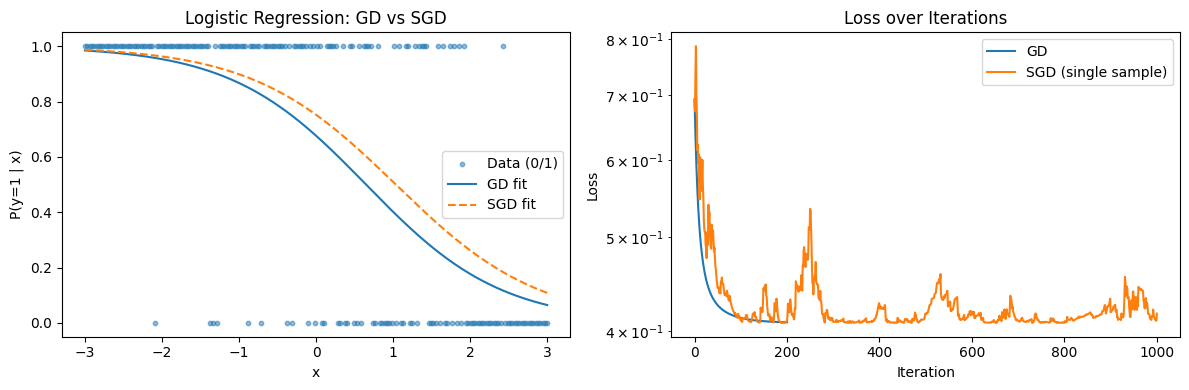

In [9]:
theta_start = np.array([0.0, 0.0])

thetas_gd, fvals_gd = run_gd(theta_start, grad_full, loss, steps=200, lr=0.1)
thetas_sgd, fvals_sgd = run_sgd(theta_start, grad_single, loss, n_data=len(x_data), steps=1000, lr=0.1)

theta_gd = thetas_gd[-1]
theta_sgd = thetas_sgd[-1]

print('Final GD theta:', theta_gd, '  loss:', loss(theta_gd))
print('Final SGD theta:', theta_sgd, '  loss:', loss(theta_sgd))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax0 = axs[0]
ax0.scatter(x_data, y_data, s=10, alpha=0.5, label='Data (0/1)')
x_plot = np.linspace(-3, 3, 400)
ax0.plot(x_plot, model(theta_gd, x_plot), label='GD fit')
ax0.plot(x_plot, model(theta_sgd, x_plot), label='SGD fit', linestyle='--')
ax0.set_xlabel('x')
ax0.set_ylabel('P(y=1 | x)')
ax0.set_title('Logistic Regression: GD vs SGD')
ax0.legend()

ax1 = axs[1]
ax1.semilogy(fvals_gd, label='GD')
ax1.semilogy(fvals_sgd, label='SGD (single sample)')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss')
ax1.set_title('Loss over Iterations')
ax1.legend()

plt.tight_layout()
plt.show()

if nbviz_available:
    cl.nbviz.savefig('logistic_gd_vs_sgd')

### Remarks and Modularity

- **Section A** used Rosenbrock to give geometric intuition for gradient-based methods.
- **Section B** showed how SGD naturally arises when the loss is a sum over data points.

The logistic example is modular:
- To try a different model or loss, define new versions of
  `model(theta, x)`, `loss(theta)`, `grad_full(theta)`, and `grad_single(theta, i)`.
- Then call `run_gd` and `run_sgd` with those functions.

This pattern generalizes to many other settings in optimization and machine learning, and
can be plugged into your MATH 565 notebooks as a compact demonstration of GD vs SGD.